In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [89]:
# #https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression/data

In [90]:
df = pd.read_csv('Student_Performance.csv')

In [91]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [93]:
# Replaced "Yes" and "No" with 1 and 0.
df["Extracurricular Activities"] = df["Extracurricular Activities"].replace({"Yes": 1, "No": 0})

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


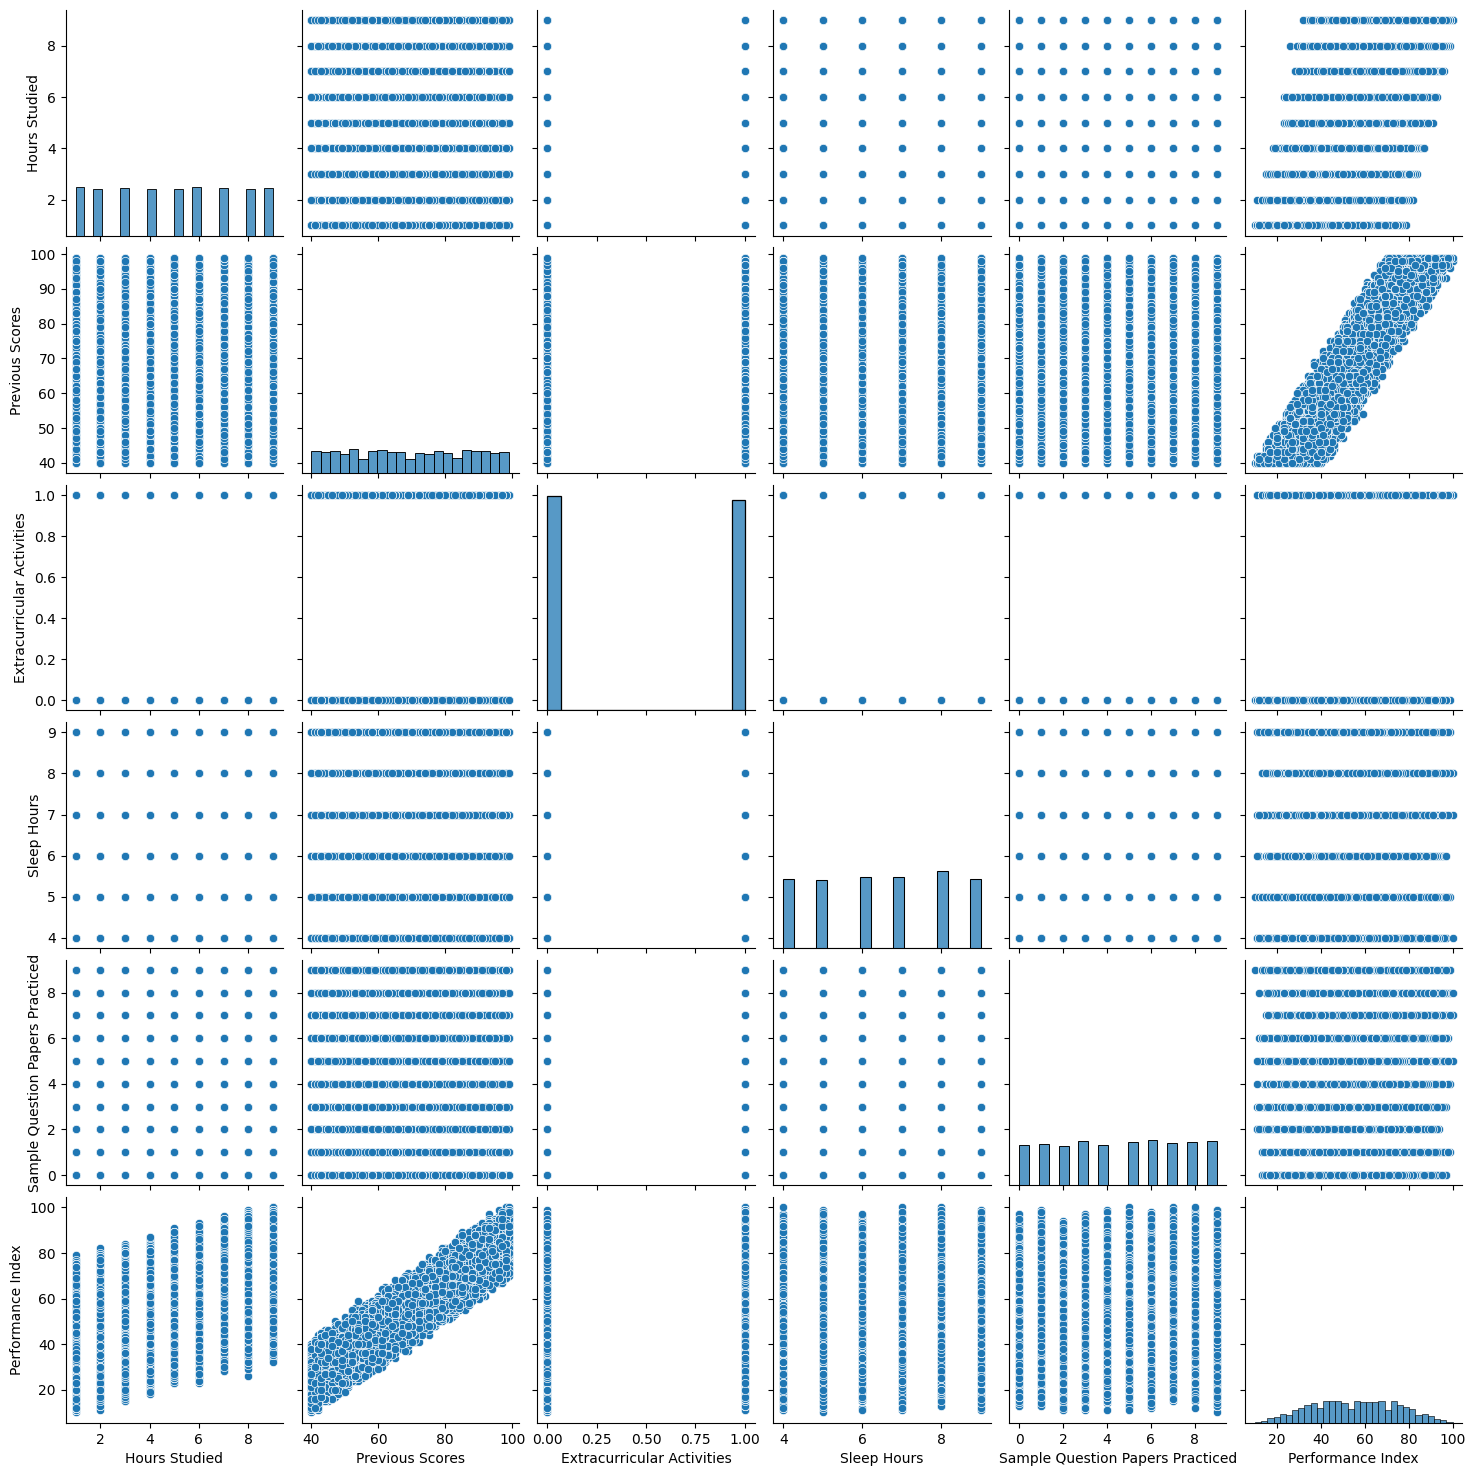

In [95]:
sns.pairplot(df)
plt.show()

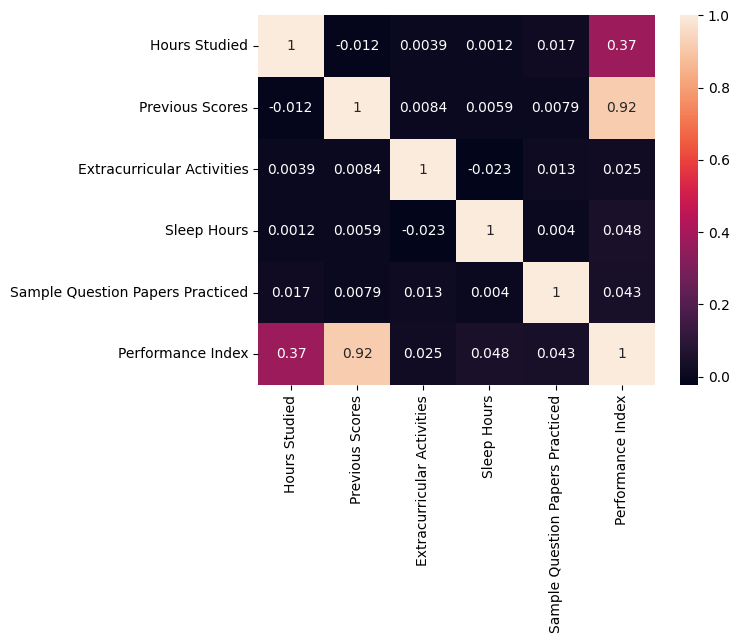

In [96]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [97]:
# Building the Models

In [98]:
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [100]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [101]:
param_tree = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
     "splitter": ["best", "random"],
     "max_features": ["sqrt", "log2",None],
     "max_depth": [1,3,5,15]
}

In [102]:
grid = GridSearchCV(estimator=DecisionTreeRegressor(), param_grid=param_tree, cv=5, scoring="r2")

In [103]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'splitter': ['best', 'random']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [104]:
grid.best_params_

{'criterion': 'absolute_error',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'random'}

In [105]:
y_pred = grid.predict(X_test)

In [106]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.9773899107876731
MSE:  8.367083333333333
MAE:  2.2635


In [107]:
#The Decision Tree achieved an R² score of 0.98, which indicates excellent performance.

In [108]:
tree_model = DecisionTreeRegressor(criterion="squared_error", max_depth=4, max_features=None, splitter='random', random_state=42)
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'random'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [109]:
y_pred = tree_model.predict(X_test)

In [110]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.8807388172777685
MSE:  44.1337601500827
MAE:  5.2749555024422214


In [120]:
# The best parameter for `max_depth` was 15, but visualizing such a deep tree would take too long.  
# Therefore, we pruned the tree by setting `max_depth=4`.  
# Although the R² score decreases, this allows faster visualization and easier inspection of the tree structure.

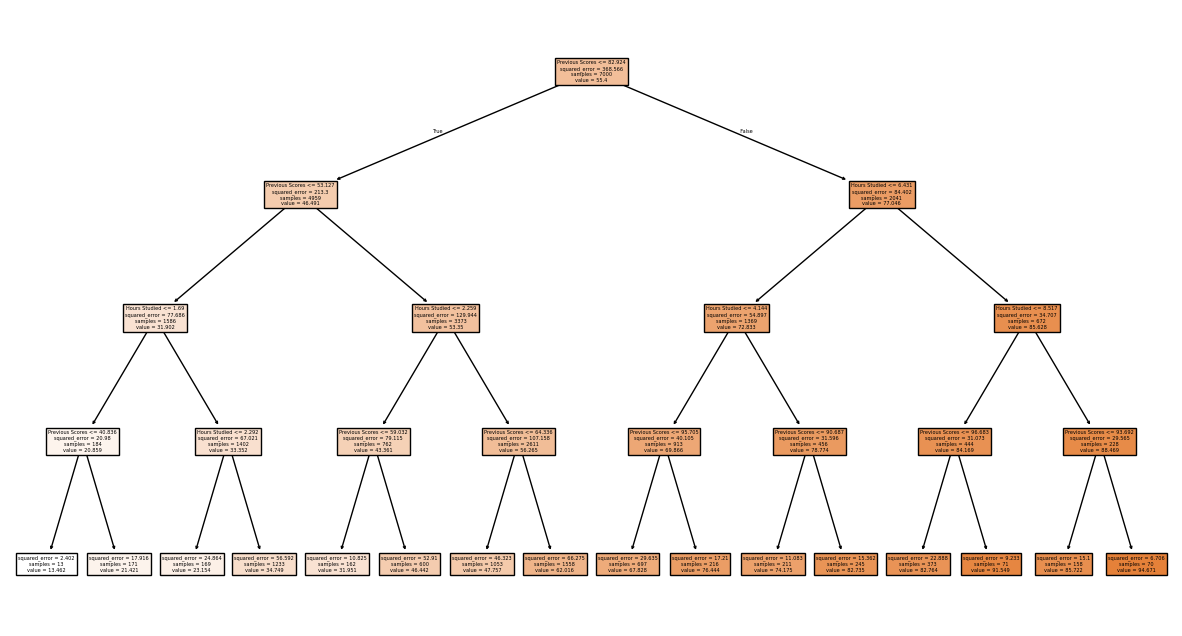

In [111]:
plt.figure(figsize=(15,8))
from sklearn import tree
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names=X_train.columns, filled=True)
plt.show()

In [121]:
# Next, we will calculate and compare the results of Linear, Ridge, Lasso, and Elastic Net regression models.

In [112]:
linear = LinearRegression()
linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [113]:
y_pred = linear.predict(X_test)

In [114]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.9890110607021136
MSE:  4.066563824092691
MAE:  1.6090437564045241


In [115]:
ridge = Ridge()
ridge.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [116]:
y_pred = ridge.predict(X_test)

In [117]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.989011047421848
MSE:  4.0665687385841265
MAE:  1.6090417453699526


In [118]:
lasso = Lasso()
lasso.fit(X_train,y_train)
y_pred = lasso.predict(X_test)

print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.9870016695439473
MSE:  4.810158557919515
MAE:  1.7342183863292169


In [119]:
elasticnet = ElasticNet()
elasticnet.fit(X_train,y_train)
y_pred = elasticnet.predict(X_test)

print("R2 Score: ", r2_score(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test,y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 Score:  0.9870576320318506
MSE:  4.78944909519117
MAE:  1.7268200058291683
